In [1]:
import pandas as pd
import pandas_ta as ta
from datetime import datetime
import dukascopy_python
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Dukascopy uses specific instrument constants
from dukascopy_python.instruments import INSTRUMENT_FX_MAJORS_EUR_USD

pd.set_option('display.max_columns', None)

In [2]:
def calculate_garman_klass(df, window=30):
    # 1. Calculate the components of the Garman-Klass formula
    log_hl = np.log(df['high'] / df['low'])
    log_co = np.log(df['close'] / df['open'])
    
    # 2. Apply the formula
    # GK = 0.5 * (ln(H/L))^2 - (2*ln(2) - 1) * (ln(C/O))^2
    gk_variant = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
    
    # 3. Rolling average to get the volatility estimate
    # df['vol_gk'] = np.sqrt(gk_variant.rolling(window=window).mean())
    return np.sqrt(gk_variant.rolling(window=window).mean()).rename("gk")

In [3]:
print("Fetching EUR/USD from Dukascopy...")

instrument = 'EUR/USD'

# Define your timeframe
start_date = datetime(2020, 1, 1)
end_date = datetime(2025, 1, 1)

# Fetch 1-Hour candles (Bid side)
df_bid = dukascopy_python.fetch(
    instrument=instrument,
    interval=dukascopy_python.INTERVAL_HOUR_1,
    offer_side=dukascopy_python.OFFER_SIDE_BID,
    start=start_date,
    end=end_date
)

df_ask = dukascopy_python.fetch(
    instrument=instrument,
    interval=dukascopy_python.INTERVAL_HOUR_1,
    offer_side=dukascopy_python.OFFER_SIDE_ASK,
    start=start_date,
    end=end_date
)

df = pd.concat([df_bid.add_suffix("_bid"), df_ask.add_suffix("_ask")], axis=1)

# Vectorized mid-price
mid_ohlc = (df[['open_bid', 'high_bid', 'low_bid', 'close_bid']].values + 
            df[['open_ask', 'high_ask', 'low_ask', 'close_ask']].values) / 2

# Assign back to DataFrame
df[['open', 'high', 'low', 'close']] = mid_ohlc
df['spread'] = df['close_ask'] - df['close_bid']
df.index = pd.to_datetime(df.index, unit='ms', utc=True)

Fetching EUR/USD from Dukascopy...


INFO:DUKASCRIPT:current timestamp :2024-10-22T01:00:00
INFO:DUKASCRIPT:current timestamp :2024-10-22T01:00:00


In [4]:
features_window_list = [3,6,9,12,24]

df_features = df.copy()
df_list = []

df_features['hour_sin'] = np.sin(2 * np.pi * df_features.index.hour / 24)
df_features['hour_cos'] = np.cos(2 * np.pi * df_features.index.hour / 24)
df_features['day'] = df_features.index.day
df_features['day_of_week'] = df_features.index.dayofweek
df_features['month'] = df_features.index.month
df_features['wick_ratio'] = abs(df_features['close'] - df_features['open'])/(df_features['high'] - df_features['low'])
df_features['green'] = (df_features['close'] - df_features['open'] > 0).astype(int)
df_features['red'] = (df_features['close'] - df_features['open'] < 0).astype(int)
# df_features['vol_imbalance'] = (df_features['volume_bid'] - df_features['volume_ask']) / (df_features['volume_bid'] + df_features['volume_ask'])
df_list.append(df_features)

adx_period = 14
df_adx = df_features.ta.adx(adx_period)
df_adx[f'ADX_P_N_DIFF_{adx_period}'] = df_adx[f'DMP_{adx_period}'] - df_adx[f'DMN_{adx_period}']
df_list.append(df_adx)

slow_sma_period = 200
df_slow_sma = df_features.ta.sma(length=slow_sma_period, close='close')
# df_list.append(df_slow_sma)

df_price_diff_slow_ma = (df['close'] - df_slow_sma).rename(f"sma_{slow_sma_period}_diff")
df_list.append(df_price_diff_slow_ma)

fast_sma_period = 50
df_fast_sma = df_features.ta.sma(length=fast_sma_period, close='close')
# df_list.append(df_fast_sma)

df_price_diff_fast_ma = (df['close'] - df_fast_sma).rename(f"sma_{fast_sma_period}_diff")
df_list.append(df_price_diff_fast_ma)

df_sma_diff = (df_fast_sma - df_slow_sma).rename(f"sma_{fast_sma_period}-{slow_sma_period}")
df_list.append(df_sma_diff)

df_price_diff_slow_ma_pct = ((df['close'] - df_slow_sma) / df['close']).rename(f"sma_{slow_sma_period}_diff_pct")
df_list.append(df_price_diff_slow_ma_pct)

df_price_diff_fast_ma_pct = ((df['close'] - df_fast_sma) / df['close']).rename(f"sma_{fast_sma_period}_diff_pct")
df_list.append(df_price_diff_fast_ma_pct)

# roc_period = 5
# df_sma_diff_roc = df_sma_diff.pct_change(roc_period).rename(f"sma_diff_roc_{roc_period}")
# df_list.append(df_sma_diff_roc)
# df_slow_sma_roc = df_slow_sma.pct_change(roc_period).rename(f"slow_sma_roc_{roc_period}")
# df_list.append(df_slow_sma_roc)
# df_fast_sma_roc = df_fast_sma.pct_change(roc_period).rename(f"fast_sma_roc_{roc_period}")
# df_list.append(df_fast_sma_roc)

atr_period = 14
df_atr = df_features.ta.atr(atr_period)
df_list.append(df_atr)

std_period = 14
df_std = df_features['close'].rolling(std_period).std()
df_list.append(df_std)

bb_period = 14
bb_std = 2.0
df_bb = df_features.ta.bbands(length=bb_period,std=bb_std)
df_list.append(df_bb)

rsi_period = 14
df_rsi = df_features.ta.rsi(rsi_period)
df_list.append(df_rsi)

macd_period = 14
df_macd = df_features.ta.macd(macd_period)
df_list.append(df_macd)

kc_period = 20
kc_scalar = 2
df_kc = df_features.ta.kc(length=kc_period, scalar=kc_scalar)
df_list.append(df_kc)

gk_period = 30
df_gk = calculate_garman_klass(df_features, window=gk_period)
df_list.append(df_gk)

roc_col_list = []
for i in features_window_list:
    close_roc_name = f'close_roc_{i}'
    df_features[close_roc_name] = df_features['close'].pct_change(i)
    roc_col_list.append(close_roc_name)

    close_abs_roc_name = f'close_abs_roc_{i}'
    df_features[close_abs_roc_name] = abs(df_features[close_roc_name])
    roc_col_list.append(close_abs_roc_name)

    for col in df_adx.columns:
        temp_adx_roc_name = f'{col}_roc_{i}'
        df_features[temp_adx_roc_name] = df_adx[col].pct_change(i)
        roc_col_list.append(temp_adx_roc_name)
    
    slow_sma_roc_name = f"sma_{slow_sma_period}_roc_{i}"
    df_features[slow_sma_roc_name] = df_slow_sma.pct_change(i)
    roc_col_list.append(slow_sma_roc_name)

    price_diff_slow_ma_roc_name = f"price_diff_slow_ma_roc_{i}"
    df_features[price_diff_slow_ma_roc_name] = df_price_diff_slow_ma.pct_change(i)
    roc_col_list.append(price_diff_slow_ma_roc_name)

    fast_sma_roc_name = f"sma_{fast_sma_period}_roc_{i}"
    df_features[fast_sma_roc_name] = df_fast_sma.pct_change(i)
    roc_col_list.append(fast_sma_roc_name)

    price_diff_fast_ma_roc_name = f"price_diff_fast_ma_roc_{i}"
    df_features[price_diff_fast_ma_roc_name] = df_price_diff_fast_ma.pct_change(i)
    roc_col_list.append(price_diff_fast_ma_roc_name)

    sma_diff_roc_name = f"sma_diff_ma_roc_{i}"
    df_features[sma_diff_roc_name] = df_sma_diff.pct_change(i)
    roc_col_list.append(sma_diff_roc_name)

    atr_roc_name = f"atr_roc_{i}"
    df_features[atr_roc_name] = df_atr.pct_change(i)
    roc_col_list.append(atr_roc_name)

    std_roc_name = f"std_roc_{i}"
    df_features[std_roc_name] = df_std.pct_change(i)
    roc_col_list.append(std_roc_name)

    rsi_roc_name = f"rsi_roc_{i}"
    df_features[rsi_roc_name] = df_rsi.pct_change(i)
    roc_col_list.append(rsi_roc_name)

    gk_roc_name = f"gk_roc_{i}"
    df_features[gk_roc_name] = df_gk.pct_change(i)
    roc_col_list.append(gk_roc_name)

smoothed_series_list = []
for roc_col in roc_col_list:
    for i in features_window_list:
        temp_smoothed_series = df_features[roc_col].rolling(i).mean()
        temp_smoothed_series.name = f"smoothed_{i}_{roc_col}"
        smoothed_series_list.append(temp_smoothed_series)
df_list.extend(smoothed_series_list)
df_features = pd.concat(df_list, axis=1)
df_features.drop(columns=['open_bid', 'high_bid', 'low_bid', 'close_bid', 'open_ask', 'high_ask', 'low_ask', 'close_ask', 'open', 'high', 'low', 'close'], inplace=True)

In [5]:
df_target = df.copy()

target_pct = 0.0015

for i in [1,3,6,9,12,24]:
    df_target[f'close_{i}'] = df_target['close'].shift(-i)
    df_target[f'target_close_pct_change_{i}'] = (df_target[f'close_{i}'] - df_target['close'])/df_target['close']
    df_target[f'target_close_abs_pct_change_{i}'] = df_target[f'target_close_pct_change_{i}'].abs()
    df_target[f'target_green_{i}'] = (df_target[f'target_close_pct_change_{i}'] > 0).astype(int)
    df_target[f'target_red_{i}'] = (df_target[f'target_close_pct_change_{i}'] < 0).astype(int)
    df_target[f'target_pct_hit_{i}'] = (df_target[f'target_close_abs_pct_change_{i}'] > target_pct).astype(int)
cols_to_drop = [c for c in df_target.columns if not c.startswith('target')]
df_target = df_target.drop(columns=cols_to_drop)

In [6]:
df_combined = pd.concat([df_features, df_target], axis=1).dropna()

In [ ]:
def analyze_feature_bins(df_original, feature_cols, target_cols, n_bins=10):
    df = df_original.copy()
    all_results = []

    for f_col in feature_cols:
        # 1. Create Bins for the specific feature
        # Using qcut ensures each bin has roughly the same number of rows
        try:
            if df[f_col].nunique() <= 50:
                # It's binary (0 or 1). Use the raw values!
                df[f'{f_col}_bin'] = df[f_col]
            else:
                df[f'{f_col}_bin'] = pd.qcut(df[f_col].rank(method='first'), q=n_bins, labels=False)
        except ValueError:
            continue # Skip features that cannot be binned

        # 2. Group by the bin and calculate the mean for all targets
        bin_analysis = df.groupby(f'{f_col}_bin')[target_cols].mean()
        
        # 3. Format the result for easy reading/plotting
        bin_analysis['feature'] = f_col
        bin_analysis['bin_number'] = bin_analysis.index
        all_results.append(bin_analysis)

    return pd.concat(all_results).reset_index(drop=True)

# Define which columns are features vs targets
feature_names = [c for c in df_features.columns] # All columns from your df_features
target_names = [c for c in df_target.columns if 'target_green' in c or 'target_red' in c or 'target_pct_hit' in c]

# Run the analysis
bin_results = analyze_feature_bins(df_combined, feature_names, target_names, n_bins=20)

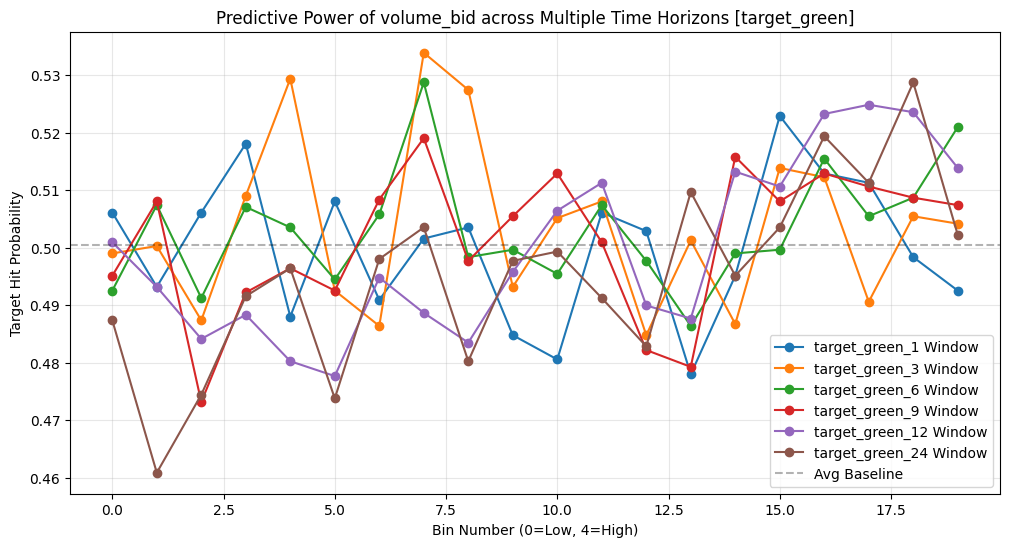

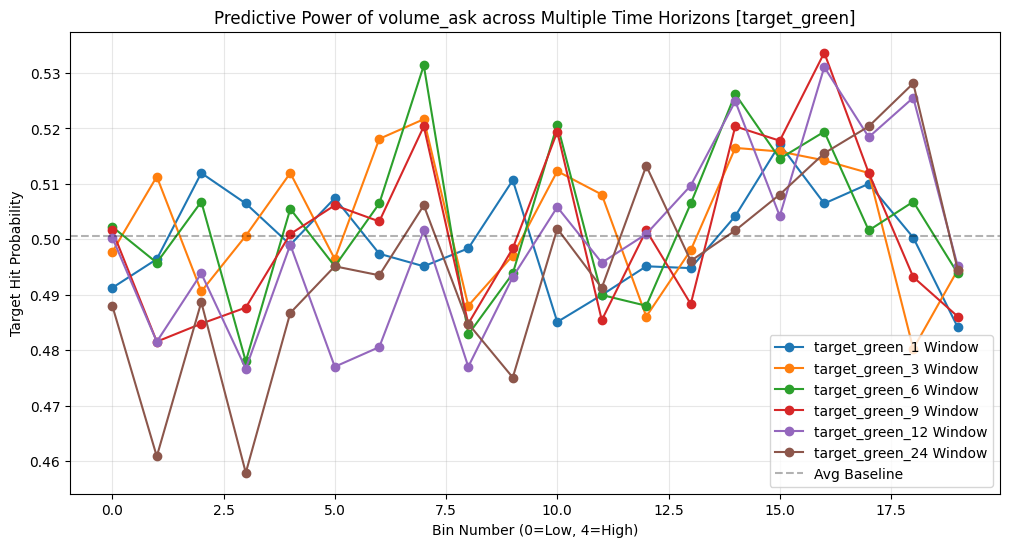

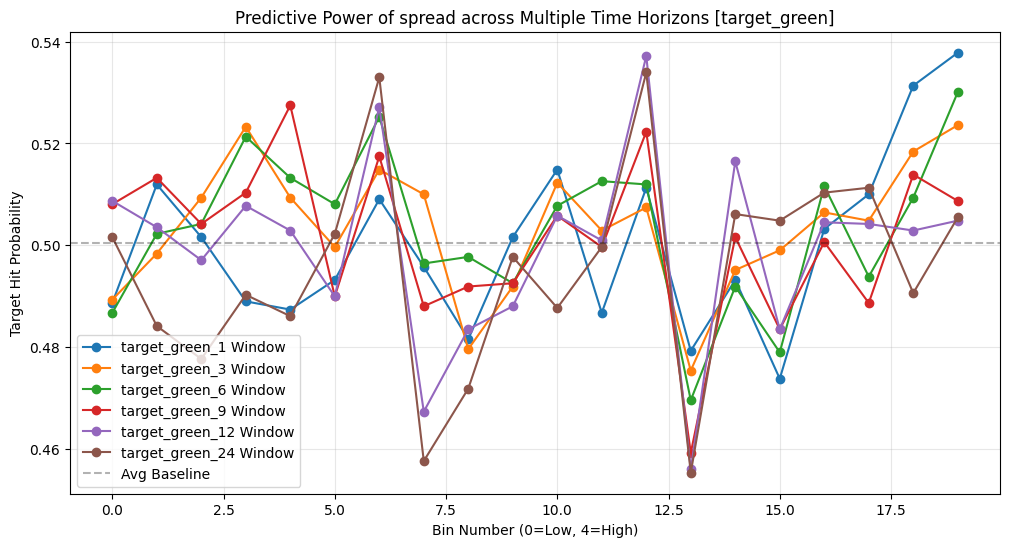

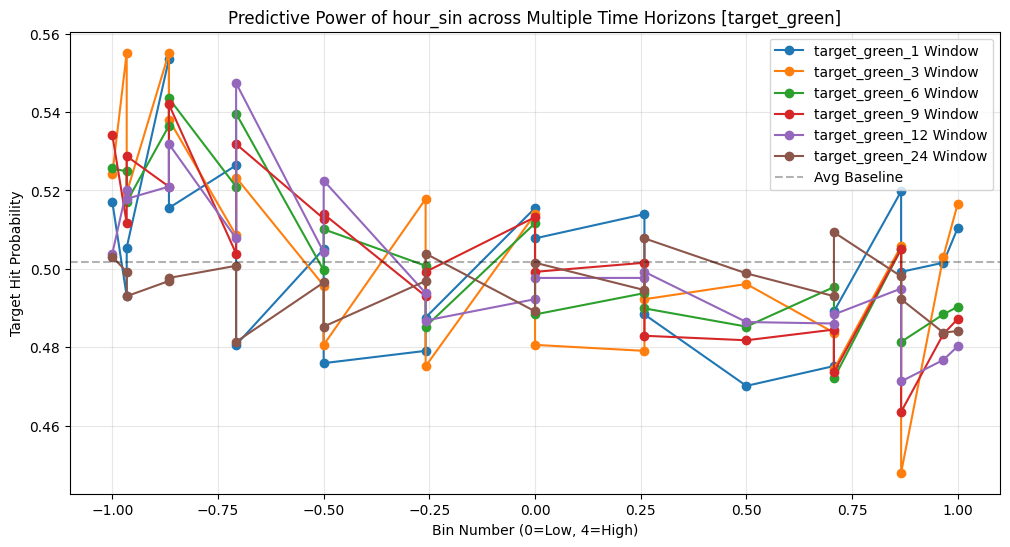

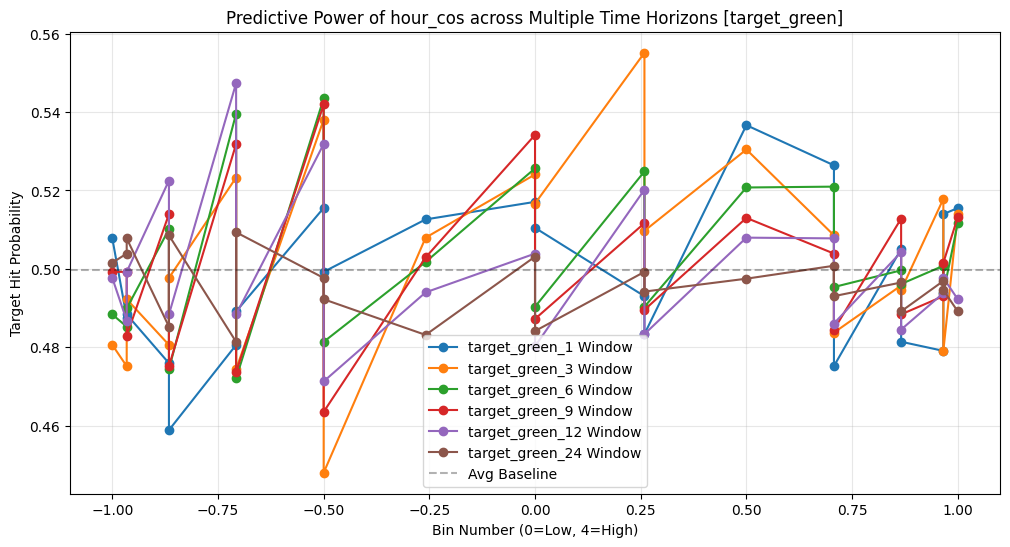

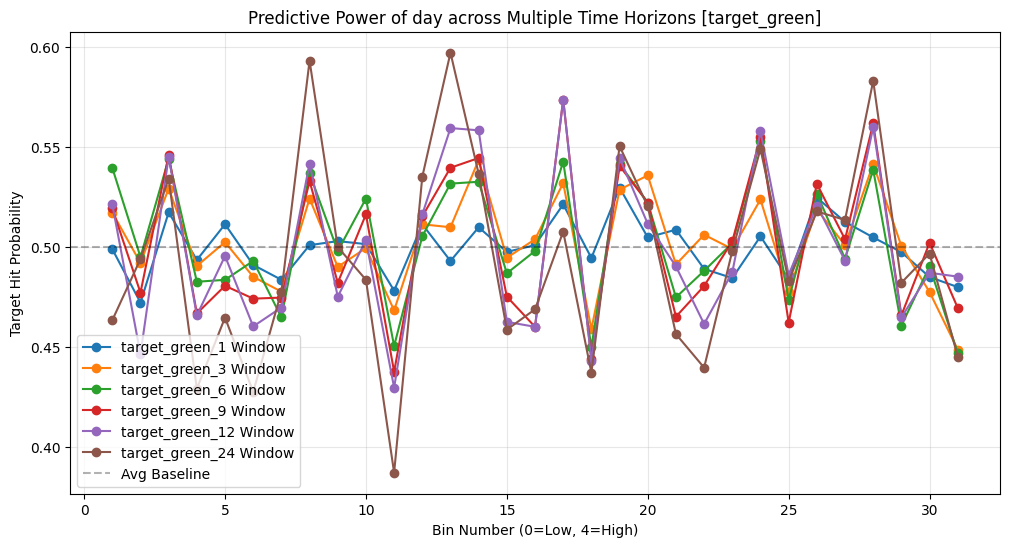

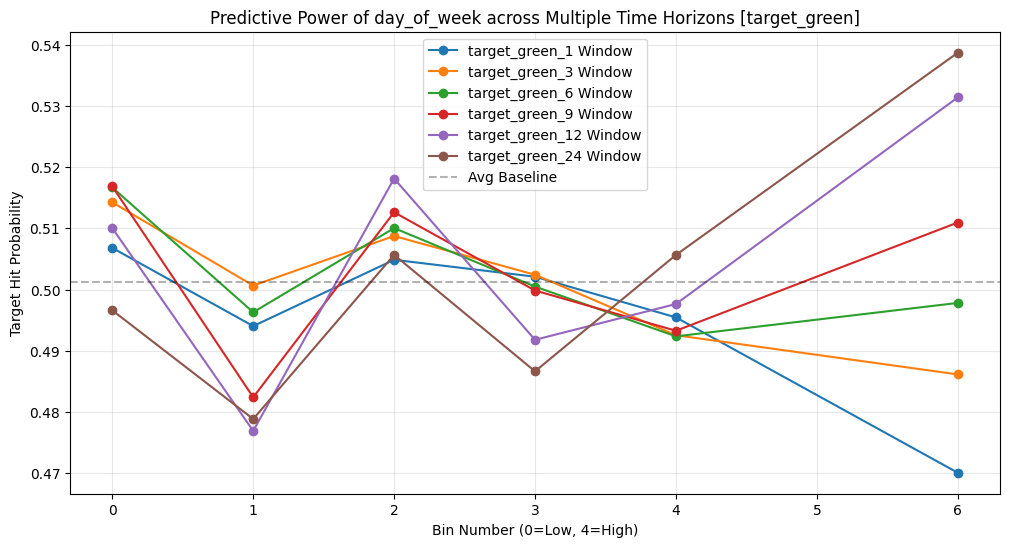

In [ ]:
def plot_feature_performance(bin_results, feature_name, target_col_prefix):
    # 1. Filter for the specific feature
    data = bin_results[bin_results['feature'] == feature_name].sort_values('bin_number')
    
    # 2. Identify the target columns (the ones we want to plot)
    # We'll filter for 'target_pct_hit' columns to see the "breakout" probability
    
    target_cols = [c for c in data.columns if target_col_prefix in c]
    
    # 3. Create the plot
    plt.figure(figsize=(12, 6))
    
    for col in target_cols:
        # We plot the bin_number on X and the mean (probability) on Y
        plt.plot(data['bin_number'], data[col], marker='o', label=col.replace("{target_col_prefix}_", '') + ' Window')

    # Add a baseline (assuming 50% is the 'random' mark, adjust if your data is imbalanced)
    plt.axhline(y=data[target_cols].values.mean(), color='black', linestyle='--', alpha=0.3, label='Avg Baseline')

    plt.title(f'Predictive Power of {feature_name} across Multiple Time Horizons [{target_col_prefix}]')
    plt.xlabel('Bin Number (0=Low, 4=High)')
    plt.ylabel('Target Hit Probability')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

for col in df_features.columns:
    plot_feature_performance(bin_results, col, target_col_prefix = 'target_green')

What matters for "target_pct_hit"
- volume_bid
- volume_ask
- ATRr_14
- KCLe_20_2
- KCUe_20_2
- gk

What matters for "target_green"
- close_roc_9
- close_roc_12
- ADX_14
- ADXR_14_2
- DMP_14
- DMN_14
- sma_50_diff
- RSI_14
- MACDh_14_26_9

What matters for "target_red"
- close_roc_3
- ADX_14
- ADXR_14_2
- DMP_14
- DMN_14
- ADX_P_N_DIFF_14
- sma_200_diff
- sma_50_diff
- fast_sma_roc_5
- RSI_14
- MACD_14_26_9
- MACDh_14_26_9
- MACDs_14_26_9

Backtest for "target_pct_hit"

In [ ]:
features_col_list = ['volume_bid', 'volume_ask', 'close_abs_roc_24', 'ATRr_14', 'BBL_14_2.0_2.0', 'BBU_14_2.0_2.0', 'MACD_14_26_9', 'MACDs_14_26_9', 'KCLe_20_2', 'KCBe_20_2', 'KCUe_20_2', 'gk']
target_pct_col_list = ['target_pct_hit_1', 'target_pct_hit_3', 'target_pct_hit_6', 'target_pct_hit_9', 'target_pct_hit_12', 'target_pct_hit_24']
target_green_col_list = ['target_green_1', 'target_green_3', 'target_green_6', 'target_green_9', 'target_green_12', 'target_green_24']
df_backtest = df_combined.copy()

In [ ]:
df_backtest.columns

Index(['volume_bid', 'volume_ask', 'spread', 'close_roc_3', 'close_abs_roc_3',
       'close_roc_6', 'close_abs_roc_6', 'close_roc_9', 'close_abs_roc_9',
       'close_roc_12', 'close_abs_roc_12', 'close_roc_24', 'close_abs_roc_24',
       'hour', 'day', 'day_of_week', 'month', 'wick_ratio', 'green', 'red',
       'ADX_14', 'ADXR_14_2', 'DMP_14', 'DMN_14', 'ADX_P_N_DIFF_14',
       'sma_200_diff', 'sma_50_diff', 'sma_50-200', 'sma_diff_roc_5',
       'slow_sma_roc_5', 'fast_sma_roc_5', 'ATRr_14', 'BBL_14_2.0_2.0',
       'BBM_14_2.0_2.0', 'BBU_14_2.0_2.0', 'BBB_14_2.0_2.0', 'BBP_14_2.0_2.0',
       'RSI_14', 'MACD_14_26_9', 'MACDh_14_26_9', 'MACDs_14_26_9', 'KCLe_20_2',
       'KCBe_20_2', 'KCUe_20_2', 'gk', 'target_close_pct_change_1',
       'target_close_abs_pct_change_1', 'target_green_1', 'target_red_1',
       'target_pct_hit_1', 'target_close_pct_change_3',
       'target_close_abs_pct_change_3', 'target_green_3', 'target_red_3',
       'target_pct_hit_3', 'target_close_pct_chan

target_pct_hit_1     0.098697
target_pct_hit_3     0.258958
target_pct_hit_6     0.403909
target_pct_hit_9     0.499349
target_pct_hit_12    0.581107
target_pct_hit_24    0.730945
dtype: float64
1736
3070
0.5654723127035831


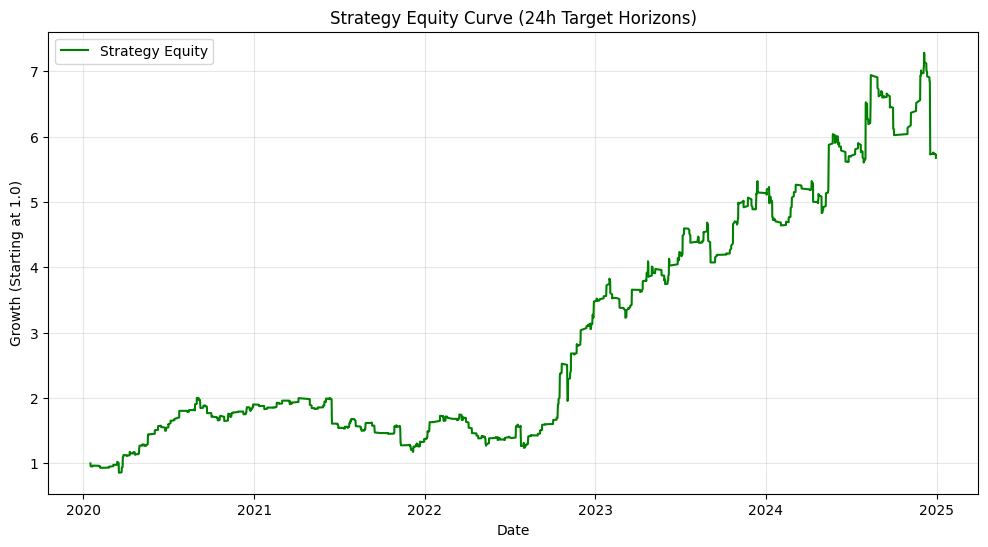

In [ ]:
# GREEN TARGET

long_mask = (
    (df_backtest['sma_diff_roc_5'] > df_backtest['sma_diff_roc_5'].quantile(0.95)) |
    (df_backtest['ADXR_14_2'] < df_backtest['ADXR_14_2'].quantile(0.05)) |
    (df_backtest['ADX_14'] < df_backtest['ADX_14'].quantile(0.05)) &
    (df_backtest['ATRr_14'] > df_backtest['ATRr_14'].quantile(0.85))
    )

df_backtest_stats = df_backtest[long_mask].copy()
print(df_backtest_stats[target_pct_col_list].mean())

# df_results = df_backtest_stats[df_backtest_stats['target_green_24'] == 1]
target_count = len(df_backtest_stats[df_backtest_stats['target_green_24'] == 1])
total_count = len(df_backtest_stats)
print(target_count)
print(total_count)
print(target_count/total_count)

df_backtest_stats['signal_return'] = 0.0
df_backtest_stats.loc[long_mask, 'signal_return'] = df_backtest_stats['target_close_pct_change_24']
df_backtest_stats['equity_curve'] = (1 + df_backtest_stats['signal_return']).cumprod()
plt.figure(figsize=(12, 6))

# Plot the Equity Curve
plt.plot(df_backtest_stats.index, df_backtest_stats['equity_curve'], label='Strategy Equity', color='green')

# Optional: Plot a Baseline (Cumulative returns of the asset itself)
# asset_benchmark = (1 + df_backtest_stats['close'].pct_change()).cumprod()
# plt.plot(df_backtest_stats.index, asset_benchmark, label='Benchmark (Buy & Hold)', alpha=0.5, color='gray')

plt.title('Strategy Equity Curve (24h Target Horizons)')
plt.xlabel('Date')
plt.ylabel('Growth (Starting at 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
df_backtest[
    # (df_backtest['volume_bid'] > df_backtest['volume_bid'].quantile(0.75)) |
    # (df_backtest['volume_ask'] > df_backtest['volume_ask'].quantile(0.75)) |
    # (df_backtest['close_abs_roc_24'] > df_backtest['close_abs_roc_24'].quantile(0.85)) |
    # (df_backtest['ATRr_14'] > df_backtest['ATRr_14'].quantile(0.75)) |
    # (df_backtest['BBL_14_2.0_2.0'] < df_backtest['BBL_14_2.0_2.0'].quantile(0.15)) |
    # (df_backtest['BBU_14_2.0_2.0'] < df_backtest['BBU_14_2.0_2.0'].quantile(0.15)) |
    # (df_backtest['MACD_14_26_9'] > df_backtest['MACD_14_26_9'].quantile(0.85)) |
    # (df_backtest['MACDs_14_26_9'] > df_backtest['MACDs_14_26_9'].quantile(0.90)) |
    # (df_backtest['KCLe_20_2'] < df_backtest['KCLe_20_2'].quantile(0.15)) |
    # (df_backtest['KCBe_20_2'] < df_backtest['KCBe_20_2'].quantile(0.15)) |
    # (df_backtest['KCUe_20_2'] < df_backtest['KCUe_20_2'].quantile(0.15)) |
    (df_backtest['gk'] > df_backtest['gk'].quantile(0.75))
][target_col_list].mean()

NameError: name 'target_col_list' is not defined